# Convolutional Neural Networks (CNN) for Soil Type Classification

**Learning Objectives:**
- Understand CNN architecture for image classification
- Learn data augmentation techniques for small datasets
- Build a CNN classifier in PyTorch
- Evaluate model performance with confusion matrix and metrics

**Exercise:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/04-cnn/04a-cnn-soil-classification-exercise.ipynb)
**Solution:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/04-cnn/04a-cnn-soil-classification.ipynb)

**Dataset:** Soil type images organized in folders by class
- Black Soil
- Cinder Soil
- Laterite Soil
- Peat Soil
- Yellow Soil

## 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from pathlib import Path
from tqdm.auto import tqdm

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Set device - prioritize MPS (Apple Silicon GPU)
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("🚀 Using Apple Silicon GPU (MPS) for acceleration!")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("🚀 Using NVIDIA GPU (CUDA)")
else:
    device = torch.device('cpu')
    print("⚠️  Using CPU (this will be slow)")

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

🚀 Using Apple Silicon GPU (MPS) for acceleration!
Device: mps
PyTorch version: 2.14.0


In [2]:
# Fetch the dataset. -nc keeps an existing local copy, so a re-run does not
# create "Soil types.zip.1". If the file already sits next to the notebook
# (as it does in the course repository), nothing is downloaded.
import os

if not os.path.exists('Soil types.zip'):
    !wget -nc https://github.com/kks32-courses/ai-geotech/raw/refs/heads/main/docs/04-cnn/Soil%20types.zip
else:
    print("Using the local copy of 'Soil types.zip'")


Using the local copy of 'Soil types.zip'


In [3]:
# -o overwrites without prompting on a re-run, -q keeps the listing short
!unzip -o -q 'Soil types.zip'


## 2. Explore the Dataset

The dataset is organized as follows:
```
Soil types/
├── Black Soil/
│   ├── 10.jpg
│   ├── 11.jpg
│   └── ...
├── Cinder Soil/
├── Laterite Soil/
├── Peat Soil/
└── Yellow Soil/
```

In [4]:
# Set data directory
data_dir = Path('Soil types')

# Get class names
class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir() and not d.name.startswith('.')])

print(f"📂 Found {len(class_names)} soil types:")
for i, class_name in enumerate(class_names):
    num_images = len(list((data_dir / class_name).glob('*.jpg'))) + len(list((data_dir / class_name).glob('*.png')))
    print(f"  {i}. {class_name}: {num_images} images")

total_images = sum([len(list((data_dir / c).glob('*.jpg'))) + len(list((data_dir / c).glob('*.png'))) for c in class_names])
print(f"\n📊 Total images: {total_images}")

📂 Found 5 soil types:
  0. Black Soil: 37 images
  1. Cinder Soil: 30 images
  2. Laterite Soil: 30 images
  3. Peat Soil: 30 images
  4. Yellow Soil: 29 images

📊 Total images: 156


## 3. Visualize Sample Images

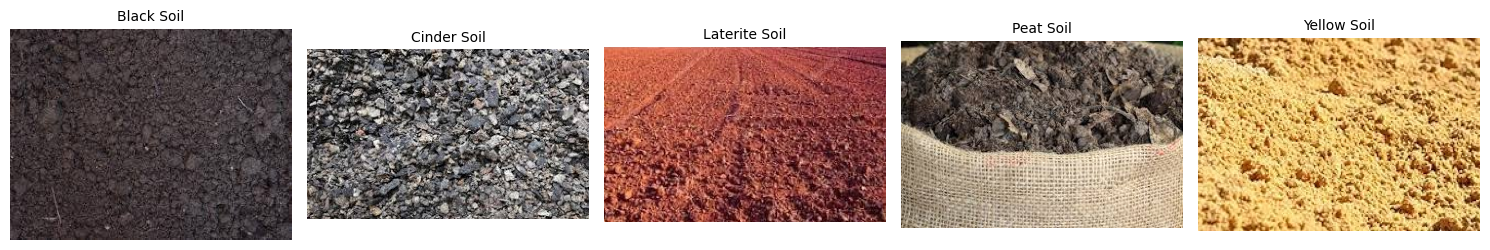

In [5]:
# Display sample images from each class
fig, axes = plt.subplots(1, len(class_names), figsize=(15, 3))

for i, class_name in enumerate(class_names):
    # Get first image from class
    img_path = list((data_dir / class_name).glob('*.jpg'))[0]
    img = Image.open(img_path)
    
    axes[i].imshow(img)
    axes[i].set_title(class_name, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 4. Data Augmentation and Preprocessing

**Why Data Augmentation?**
- Small dataset (~150 images total)
- Prevents overfitting
- Improves generalization

**Transformations:**
- Random horizontal/vertical flips
- Random rotation (±20°)
- Color jitter (brightness, contrast)
- Normalization

In [6]:
# Image size
IMG_SIZE = 224

# Training transformations (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/Test transformations (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Data augmentation pipeline created")

✅ Data augmentation pipeline created


## 5. Create Dataset and DataLoaders

In [7]:
# Load full dataset
print("📦 Loading dataset...")
full_dataset = ImageFolder(root=data_dir, transform=None)

# Split into train (70%), validation (15%), test (15%)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

print(f"\n📊 Dataset split:")
print(f"  Train: {train_size} images ({train_size/len(full_dataset)*100:.1f}%)")
print(f"  Val:   {val_size} images ({val_size/len(full_dataset)*100:.1f}%)")
print(f"  Test:  {test_size} images ({test_size/len(full_dataset)*100:.1f}%)")

# Split dataset
train_subset, val_subset, test_subset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)


class TransformedSubset(Dataset):
    """Apply a transform to a Subset.

    random_split returns Subset objects that share one underlying ImageFolder,
    so setting `subset.dataset.transform` writes the same attribute three times
    and the last assignment wins. This wrapper keeps the transform on the split
    itself and applies it in __getitem__, so only the training split is
    augmented.
    """

    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        return self.transform(image), label


# Apply transforms: augmentation on train only, plain resize on val and test
train_dataset = TransformedSubset(train_subset, train_transform)
val_dataset = TransformedSubset(val_subset, val_transform)
test_dataset = TransformedSubset(test_subset, val_transform)

# Create dataloaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\n✅ DataLoaders created (batch_size={batch_size})")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

📦 Loading dataset...

📊 Dataset split:
  Train: 109 images (69.9%)
  Val:   23 images (14.7%)
  Test:  24 images (15.4%)

✅ DataLoaders created (batch_size=16)
  Train batches: 7
  Val batches:   2
  Test batches:  2


## 6. CNN Model Architecture

**Our CNN consists of:**
- 3 Convolutional blocks (Conv → BatchNorm → ReLU → MaxPool)
- Dropout for regularization
- 2 Fully connected layers
- Output layer (5 classes)

```
Input (224x224x3)
    ↓
Conv Block 1 (32 filters, 3x3) + BatchNorm + ReLU
    ↓ MaxPool (112x112)
Conv Block 2 (64 filters, 3x3) + BatchNorm + ReLU
    ↓ MaxPool (56x56)
Conv Block 3 (128 filters, 3x3) + BatchNorm + ReLU
    ↓ MaxPool (28x28)
Flatten
    ↓
FC1 (256 units) + Dropout
    ↓
FC2 (128 units) + Dropout
    ↓
Output (5 classes)
```

In [8]:
class SoilCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(SoilCNN, self).__init__()
        
        # Convolutional Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Convolutional Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Convolutional Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Calculate flattened size: 224 -> 112 -> 56 -> 28
        self.flatten_size = 128 * 28 * 28
        
        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flatten_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x


# Create model
model = SoilCNN(num_classes=len(class_names))
model = model.to(device)

print(model)
print(f"\n📊 Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"📊 Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

SoilCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_fea

## 7. Training Configuration

In [9]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler (reduce LR on plateau)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print("✅ Training configuration:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Scheduler: ReduceLROnPlateau")

✅ Training configuration:
  Loss: CrossEntropyLoss
  Optimizer: Adam (lr=0.001)
  Scheduler: ReduceLROnPlateau


## 8. Training Function with Progress Bar

In [10]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                num_epochs=50, device='cpu'):
    """
    Train the CNN model with real-time progress tracking.
    """
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    best_val_acc = 0.0
    
    print(f"🏃 Starting training on {device}...\n")
    
    for epoch in tqdm(range(num_epochs), desc='Epochs'):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        train_loss /= len(train_loader)
        train_acc = 100 * train_correct / train_total
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total
        
        # Update history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_soil_cnn.pth')
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{num_epochs} | '
                  f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%')
    
    print(f'\n✅ Training completed! Best validation accuracy: {best_val_acc:.2f}%')
    
    # Load best model
    model.load_state_dict(torch.load('best_soil_cnn.pth'))
    
    return history

## 9. Train the Model

In [11]:
# Train the model
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=50,
    device=device
)

🏃 Starting training on mps...



Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 10/50 | Train Loss: 1.3024, Acc: 55.05% | Val Loss: 0.8184, Acc: 56.52%


Epoch 20/50 | Train Loss: 1.0084, Acc: 58.72% | Val Loss: 0.7383, Acc: 69.57%


Epoch 30/50 | Train Loss: 0.9895, Acc: 55.96% | Val Loss: 0.8365, Acc: 69.57%


Epoch 40/50 | Train Loss: 1.0002, Acc: 60.55% | Val Loss: 0.8646, Acc: 52.17%


Epoch 50/50 | Train Loss: 0.9131, Acc: 56.88% | Val Loss: 0.8537, Acc: 52.17%

✅ Training completed! Best validation accuracy: 78.26%


## 10. Visualize Training History

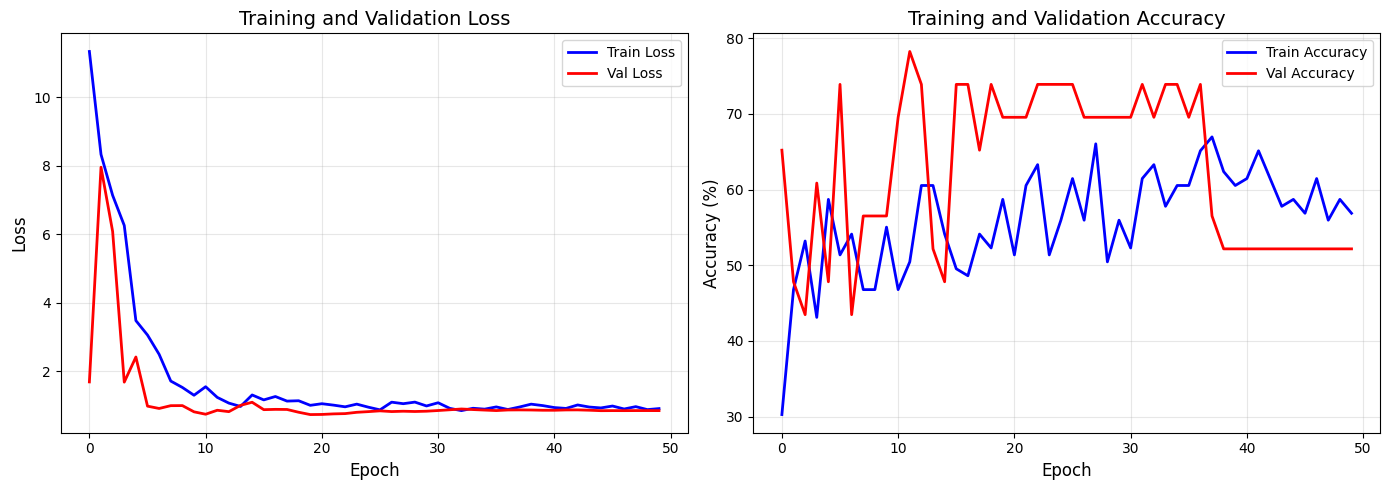

Final train accuracy: 56.88%
Final val accuracy: 52.17%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
axes[0].plot(history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
axes[1].plot(history['val_acc'], 'r-', label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final train accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Final val accuracy: {history['val_acc'][-1]:.2f}%")

## 11. Evaluate on Test Set

The test set holds 24 images, so a single image moves the accuracy by 4.2 points. The binomial standard error `sqrt(p(1-p)/24)` runs from 6 to 10 percentage points over the accuracies this model reaches. Per-class support is 3 to 6 images. Read the numbers below as rough estimates, and use k-fold cross-validation over all 156 images if you need a tighter one.

In [13]:
def evaluate_model(model, test_loader, device='cpu'):
    """
    Evaluate model on test set.
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds)


# Evaluate on test set
print("🧪 Evaluating on test set...")
test_labels, test_preds = evaluate_model(model, test_loader, device)

# Calculate accuracy
test_acc = accuracy_score(test_labels, test_preds) * 100
print(f"\n✅ Test Accuracy: {test_acc:.2f}%")

# Classification report
print("\n📊 Classification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

🧪 Evaluating on test set...



✅ Test Accuracy: 66.67%

📊 Classification Report:
               precision    recall  f1-score   support

   Black Soil       1.00      0.50      0.67         6
  Cinder Soil       0.57      1.00      0.73         4
Laterite Soil       0.43      1.00      0.60         3
    Peat Soil       0.67      0.40      0.50         5
  Yellow Soil       1.00      0.67      0.80         6

     accuracy                           0.67        24
    macro avg       0.73      0.71      0.66        24
 weighted avg       0.79      0.67      0.67        24



## 12. Confusion Matrix

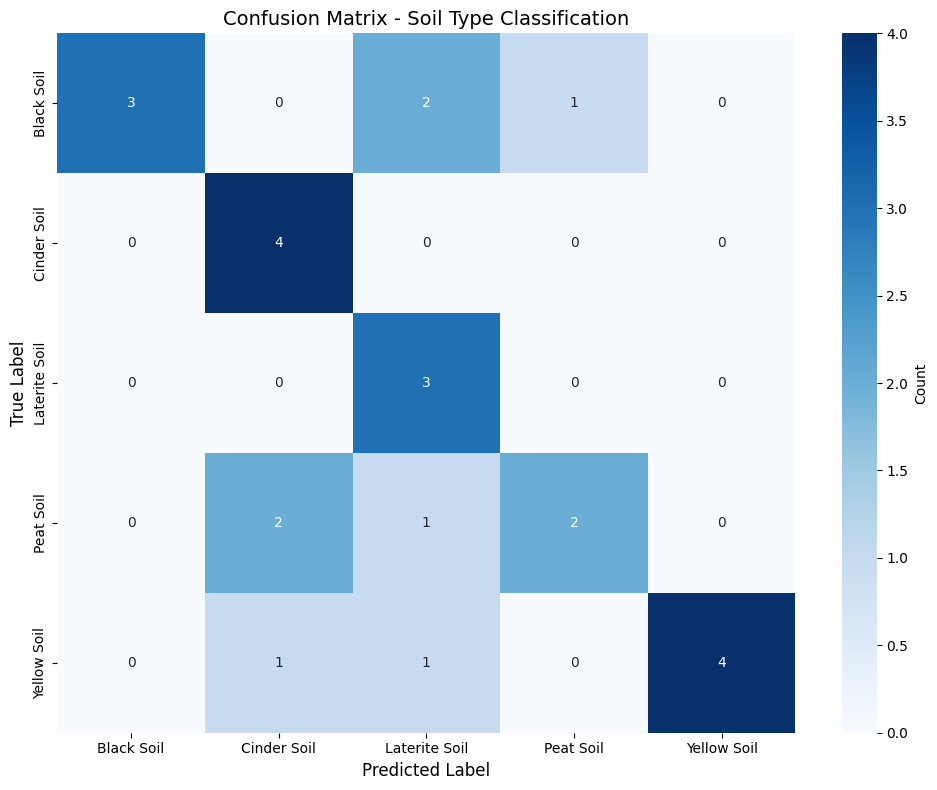

In [14]:
# Compute confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Soil Type Classification', fontsize=14)
plt.tight_layout()
plt.show()

## 13. Visualize Predictions on Test Images

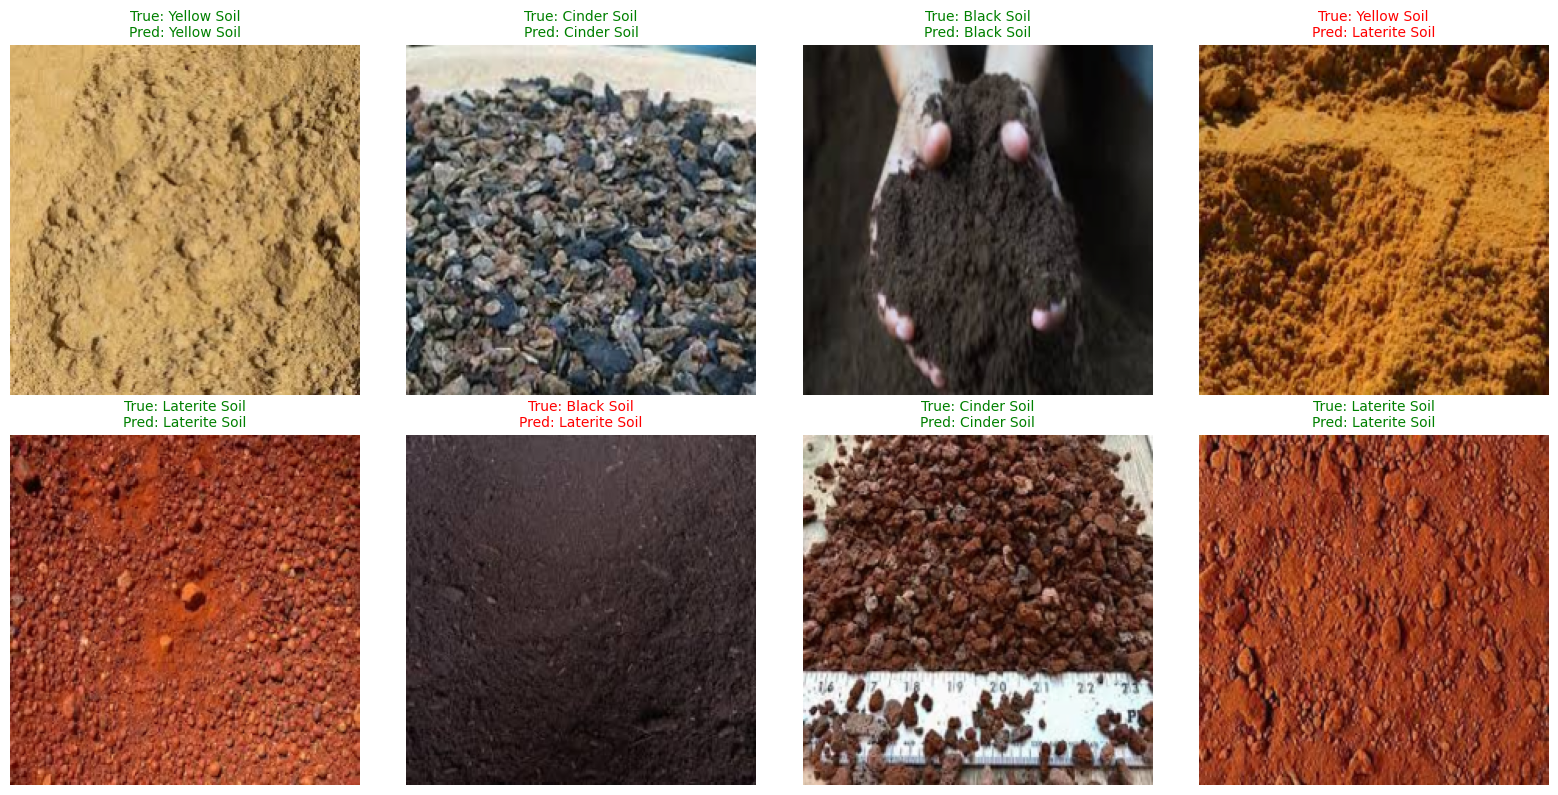

In [15]:
# Get a batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Make predictions
images_device = images.to(device)
model.eval()
with torch.no_grad():
    outputs = model(images_device)
    _, preds = torch.max(outputs, 1)

# Unnormalize images for display
def unnormalize(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# Plot predictions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(min(8, len(images))):
    img = unnormalize(images[i].cpu())
    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]
    
    axes[i].imshow(img)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 14. Summary and Key Takeaways

### What We Learned

1. **CNN Architecture for Image Classification:**
   - Convolutional layers extract spatial features
   - Pooling layers reduce dimensionality
   - Fully connected layers perform classification

2. **Data Augmentation:**
   - Essential for small datasets
   - Random flips, rotations, color jitter
   - Prevents overfitting

3. **Training Techniques:**
   - Batch normalization for stable training
   - Dropout for regularization
   - Learning rate scheduling
   - Best-model checkpointing on validation accuracy

4. **Evaluation:**
   - Confusion matrix shows per-class performance
   - Classification report provides detailed metrics
   - Visual inspection of predictions

### Applications in Geotechnical Engineering

- Automated soil classification from field images
- Quality control in construction
- Rapid site characterization
- Remote sensing and drone-based surveys